# Cut material

### P?

Old Faithful geyser 

Eruption and waiting time of Old Faithful Geyser


In [6]:
import pandas as pd
faithful = pd.read_csv("datasets/faithful.csv")

In [7]:
faithful["duration"].describe()

count    272.000000
mean       3.487783
std        1.141371
min        1.600000
25%        2.162750
50%        4.000000
75%        4.454250
max        5.100000
Name: duration, dtype: float64

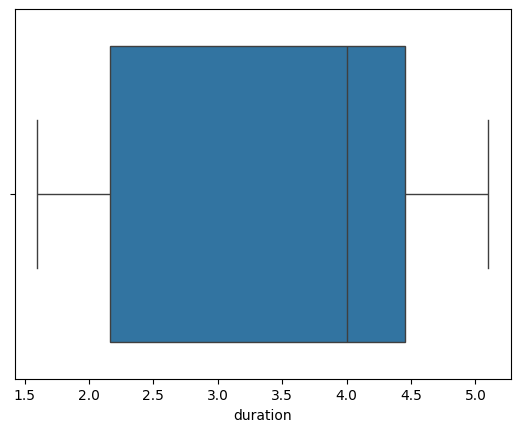

In [9]:
import seaborn as sns
sns.boxplot(data=faithful, x="duration");

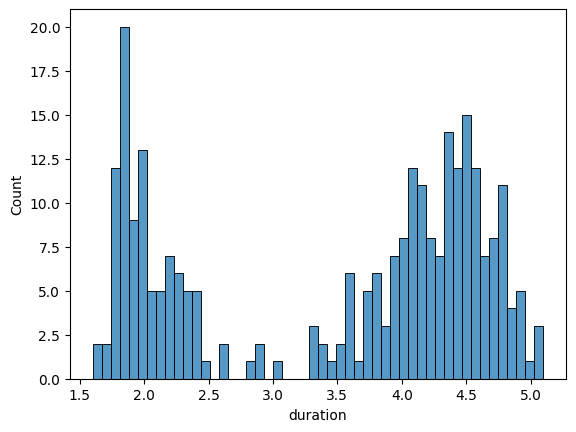

In [10]:
sns.histplot(data=faithful, x="duration", bins=50);

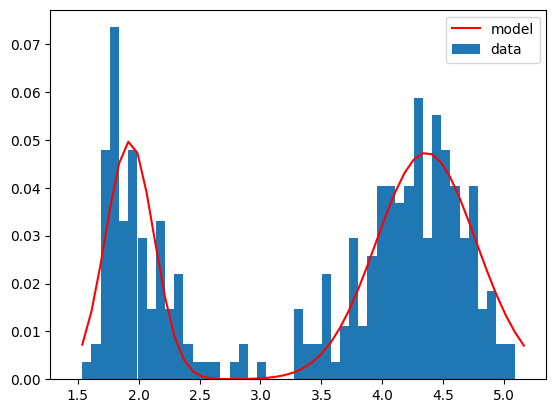

In [12]:
import numpy as np
import matplotlib.pyplot as plt


# histogram
bins = np.linspace(1.5, 5.2, 50)
hist = pd.cut(faithful["duration"], bins=bins, right=False) \
         .value_counts(sort=False, normalize=True)
bins_left = hist.index.categories.left
bins_width = hist.index.categories.length
x = hist.index.categories.mid
y = hist.values


# fit a mixture of Gaussians to the histogram
from scipy.optimize import curve_fit

def gauss(x, mu, sigma, A):
    return A*np.exp(-0.5*(x-mu)**2/sigma**2)

def bimodal(x, mu1, sigma1, A1, mu2, sigma2, A2):
    return gauss(x,mu1,sigma1,A1) + gauss(x,mu2,sigma2,A2)

p0 = (2,0.5,0.4,  4.5,0.5,0.6)
params, cov = curve_fit(bimodal, x, y, p0=p0)
plt.bar(x=bins_left, width=bins_width, height=y, label='data')
plt.plot(x, bimodal(x,*params), color='red', label='model')
plt.legend();
# params

In [16]:
howell30 = pd.read_csv("../../datasets/howell30.csv")

n = howell30.shape[0]

np.random.seed(44)
mask = np.random.choice([True,False], size=n)

intervetion_group = howell30.loc[mask]
control_group = howell30.loc[~mask]


intervetion_group["age"].mean(), control_group["age"].mean()

for column in ['age', 'weight', 'height']:
    print(column, "\t",
          "intervention group mean", intervetion_group[column].mean().round(2),
          "control group mean", control_group[column].mean().round(2))
intr_sex_counts = intervetion_group["sex"].value_counts()
ctrl_sex_counts = control_group["sex"].value_counts()
print("intervention group sex=M", intr_sex_counts["M"],
      "control group sex=M", ctrl_sex_counts["M"])
print("intervention group sex=F", intr_sex_counts["F"],
      "control group sex=F", ctrl_sex_counts["F"])

age 	 intervention group mean 13.72 control group mean 14.14
weight 	 intervention group mean 28.39 control group mean 28.31
height 	 intervention group mean 125.76 control group mean 125.6
intervention group sex=M 72 control group sex=M 64
intervention group sex=F 79 control group sex=F 83


### Problem: transformed variable

Consider the random variable $Y = \text{exp}(X)$,
where $X \sim \mathcal{N}(\mu=0,\sigma=1)$,
which corresponds to `rvX = scipy.stats.norm(0,1)`.
 
a) Find the probability density function of `rvX`.

b) Use calculus to find the probability density function of $Y$.

c) Verify your answer in (b) by 10000 random samples from `rvX` and applying the `exp` transform on them.

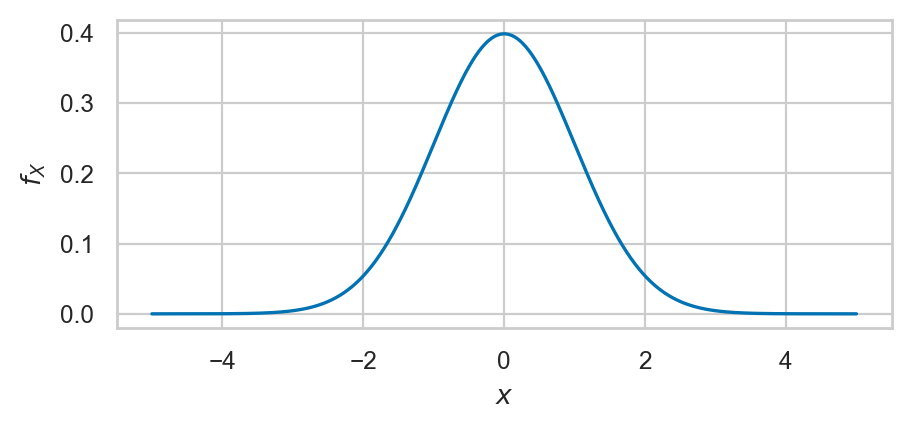

In [42]:
from scipy.stats import norm
from ministats import plot_pdf

rvX = norm(0,1)
plot_pdf(rvX, xlims=[-5,5]);

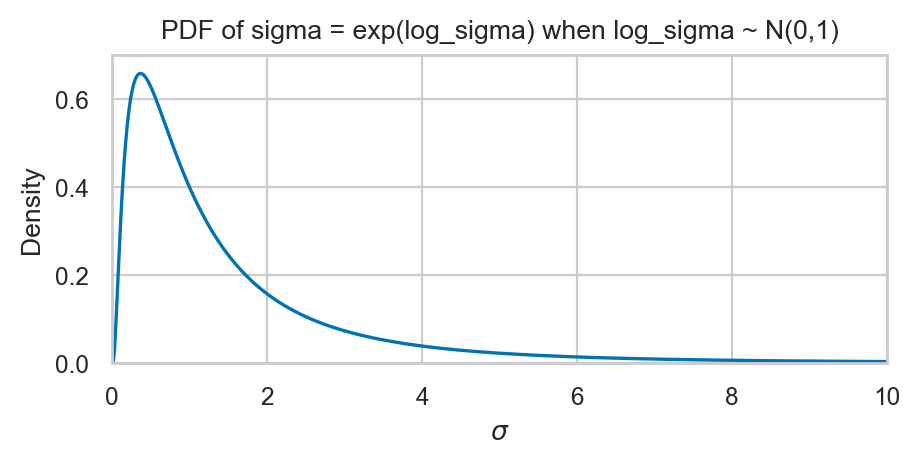

In [43]:
logsigs = np.linspace(-5, 5, 1000)
dlogsigs = norm(0,1).pdf(logsigs)
sigmas = np.exp(logsigs)
# Apply the change of variables to get the density for sigma
# based on the Jacobian adjustment |d(log(sigma))/d(sigma)| = 1/sigma
dsigmas = dlogsigs / sigmas  

# Plot the transformed density using seaborn
ax = sns.lineplot(x=sigmas, y=dsigmas)
ax.set_xlabel('$\\sigma$')
ax.set_ylabel('Density')
ax.set_title('PDF of sigma = exp(log_sigma) when log_sigma ~ N(0,1)')
ax.set_xlim(0, 10)
ax.set_ylim(0, 0.7);

(1.6513486244380393, 2.1603481268169995)

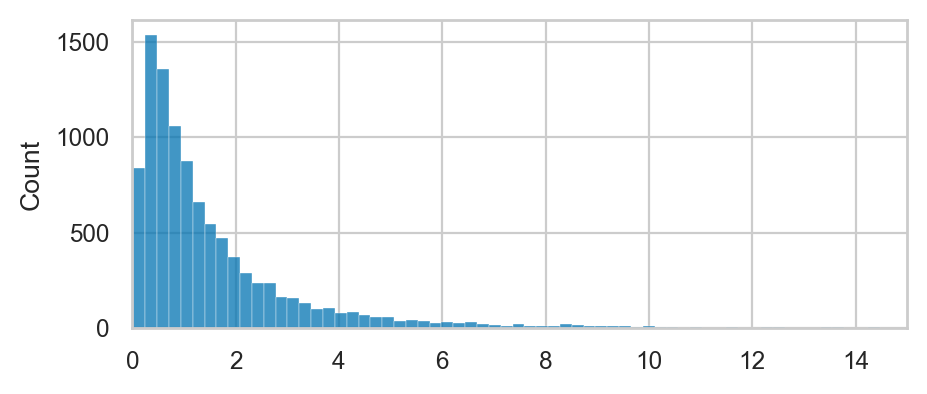

In [44]:
# verify using simulation
mu, sigma = 0, 1
N = 10000
np.random.seed(44)
logsigs = norm(mu, sigma).rvs(N)
sigs = np.exp(logsigs)
ax = sns.histplot(sigs)
ax.set_xlim(0, 15);
sigs.mean(), sigs.std(ddof=1)